## Parallel SS/SSA

In [7]:
def estimate_norm(timestep, order, r1, r2, q):
    '''
    Description:
        Helper function to estimate norm at timestep based on its histogram
    Input:
        hist: histogram to use for norms
        timestep: timestep for which to estimte order norm
        order: order of norm
        r1: number of values to take median of
        r2: number of values to take mean of
        q: threshold of ssa algorithm
    Returns:
        Order norm at timestep
    '''
    t = hist_ssa[timestep] # keeps track of samples
    r1_norms = []
    for i in range(r1):
        r2_norms = []
        t_i = t[i] # sample for current iteration
        for j in range(r2):
            curr_t = t_i[j]
            moment = np.sum(np.power(list(curr_t.values()), order))
            r2_norms.append(
                    np.power((1/q * moment), 1/order)
                )
        r1_norms.append(np.mean(r2_norms))
    rest_est = np.median(r1_norms)
    temp_arr = np.concatenate((hist_hh_sums[timestep], [rest_est]))
    return np.linalg.norm(temp_arr, order)

In [8]:
def prune_threads_ssa(order, r1, r2, q):
    '''
    Description:
        Removes adjacent threads that are within a threshold of 2
    Inputs:
        order: order of norm
        r1: number of values to take median of
        r2: number of values to take mean of
        q: threshold for ssa algorithm
    '''
    i = 0 # index variable
    while (i < len(threads_vec_ssa)):
        # boundary check
        if (i >= len(threads_vec_ssa) - 2):
            return
        t_i = threads_vec_ssa[i] # thread identity
        ssa_ti = estimate_norm(t_i, order, r1, r2, q) # ssa estimate for thread

        t_i2 = threads_vec_ssa[i+2] # adjcaent thread
        ssa_ti2 = estimate_norm(t_i2, order, r1, r2, q) # ssa estimate for adjancent thread
        
        # check distance, prune hist, threads
        denom = min(ssa_ti, ssa_ti2)
        if (denom != 0 and (max(ssa_ti, ssa_ti2)/denom <= 2)):
            # remove the thread in between
            t_i1 = threads_vec_ssa[i+1]
            threads_vec_ssa.pop(i+1)
            hist_ssa.pop(t_i1)
            hist_ss.pop(t_i1)
            hist_hh_sums.pop(t_i1)
            i -= 1
        i += 1

In [9]:
def spawn_threads_ssa(timestep, order, l, r1, r2, q):
    '''
    Description:
        Helper function to spawn threads for ssa
    Inputs:
        timestep: timestep identifier to spawn threads for ssa
        order: order of norm
        l: number of heavy hitters
        r1: number of values to take median of
        r2: number of values to take mean of
        q: threshold for ssa algorithm
    '''
    if (len(threads_vec_ssa) == num_threads_max):
        prune_threads_ssa(order, r1, r2, q)
    if (len(threads_vec_ssa) < num_threads_max):
        threads_vec_ssa.append(timestep)
        hist_ssa[timestep] = [[{} for _ in range(r2)] for _ in range(r1)]
        hist_ss[timestep] = [[{} for _ in range(r2)] for _ in range(r1)]
        hist_hh_sums[timestep] = np.zeros(l)

In [10]:
def selective_subsampling(s_i, r1, r2, q):
    '''
    Description:
        Helper method to run ss in parallel with ssa
    Inputs:
        s_i: the current stream value
        r1: number of values to take median of
        r2: number of values to take mean of
        
    '''
    for thread in threads_vec_ssa:
        t = hist_ss[thread]
        for i in range(r1):
            t_i = t[i]
            for j in range(r2):
                curr_t = t_i[j]
                prob = seeded_input_random((i+1)*(j+1) + s_i, s_i)
                if (prob < q):
                    curr_t.setdefault(s_i, 0)
                    curr_t[s_i] += 1

In [ ]:
import numpy as np
from utils import seeded_input_random
import csv
import ipaddress

def selective_subsampling_augmented(heavy, filepath, order, limit, r1, r2, q, q_ss):
    '''
    Description:
        Uses augmented selective subsampling algorithm to estimate order norm of frequencies
    Inputs:
        heavy: list of heavy hitters IP addresses
        filepath: file to run algorithm on
        order: order of norm
        limit: number of addresses to process
        r1: number of values to take median of
        r2: number of values to take mean of
        q: threshold for ssa algorithm
        q_ss: threshold for ss algorithm
    Outputs:
        returns estimated order norm of frequency vector
    '''
    
    with open(filepath) as csvfile:
        stream = csv.reader(csvfile, delimiter=",")
        stream.__next__() # get rid of the header
        time = 1
        for row in stream:
            if (stream.line_num == limit):
                break
            try:
                s_i = int(ipaddress.ip_address(row[0]))
            except:
                # ip address is not valid IPv4 or IPv6 address
                continue
            vals.append(s_i)
            # run augmented algorithm
            spawn_threads_ssa(time, order, len(heavy), r1, r2, q)
            try:
                index = heavy.index(s_i)
                # s_i is a heavy hitter
                for thread in threads_vec_ssa:
                    t = hist_hh_sums[thread]
                    t[index] += 1
            except ValueError:
                # s_i is not a heavy hitter
                for thread in threads_vec_ssa:
                    t = hist_ssa[thread]
                    for i in range(r1):
                        t_i = t[i]
                        for j in range(r2):
                            curr_t = t_i[j]
                            prob = seeded_input_random((i+1)*(j+1) + s_i, s_i)
                            if (prob < q):
                                curr_t.setdefault(s_i, 0)
                                curr_t[s_i] += 1
            finally:
                # run ss in parallel
                selective_subsampling(s_i, r1, r2, q_ss)
                time += 1

## Test Parallel SS/SSA on Data - Vary Window Size

In [2]:
# from CS
hh_cs = [
 2401796176,
 3573875943,
 879396542,
 1572803056,
 3451786411,
 1298962670,
 607033987,
 2497912303,
 3339135037,
 887074222,
 1115991985,
 2613392396,
 1604957565,
 1072021340,
 2987213905,
 3124349474,
 3124349526,
 517524860,
 595152676,
 3568914218,
 2839797836,
 1039166085,
 1115974613,
 3174560376,
 3124327772,
 3016127925
 ]

In [3]:
# from lstm
hh_lstm = [2839797836,
3124349474,
3451786411,
3573875943,
2497912303,
887074222,
1412259146,
2846658931,
440106510,
2497912302,
929497735,
1189564467,
873813081,
2747212874,
3561206840,
2840977331,
509132326,
1239019302,
1138995964,
1202644715,
3673594762,
758693520,
3673593429,
2368786512,
2401809378,
3646984608]

In [5]:
import ipaddress
# from gemini
hh_gemini = ['93.191.17.217', 
                '66.132.107.213', 
                '186.57.202.86', 
                '163.104.156.57', 
                '213.5.4.231', 
                '212.185.79.42', 
                '186.57.117.92', 
                '84.115.156.13', 
                '205.190.20.171', 
                '16.25.141.229', 
                '117.152.100.47', 
                '205.190.27.212', 
                '186.57.117.104', 
                '26.69.40.26', 
                '169.91.106.25', 
                '95.169.181.125', 
                '66.132.175.177', 
                '148.227.28.170', 
                '148.227.29.239', 
                '52.193.94.101', 
                '189.55.242.120', 
                '192.75.167.251', 
                '114.56.97.199', 
                '211.148.179.99', 
                '117.164.144.24', 
                '45.227.253.244', 
                '55.28.201.238', 
                '203.108.167.37', 
                '178.13.68.81', 
                '195.188.138.42', 
                '198.171.21.225', 
                '146.55.124.107', 
                '218.183.129.45', 
                '71.186.208.112', 
                '52.223.173.174', 
                '148.227.42.103', 
                '205.190.20.136', 
                '77.108.152.238', 
                # '2158:2b7e:e7f0:7f07', 
                '25.51.107.120', 
                '93.85.164.193', 
                '30.220.161.68', 
                '66.146.187.182', 
                '148.227.29.238', 
                '30.45.186.91', 
                '124.25.147.70', 
                '93.191.17.240', 
                '143.40.128.80', 
                '16.136.231.190', 
                '169.107.218.97', 
                '169.148.229.197', 
                '52.21.84.89'
                ]
hh_gemini = [int(ipaddress.ip_address(ip)) for ip in hh_gemini]
# Keep number of hh consistent
hh_gemini = hh_gemini[:26]

In [7]:
len(set(hh_cs) & set(hh_gemini))

10

In [35]:
#setup shared variables
hist_ssa = {} # maps timestep to ssa value
hist_ss = {} # maps timestep to ss value
hist_hh_sums = {} # maps timestep to hh sum value
threads_vec_ssa = [] # stores thread identities
num_threads_max = 20 # hyperparam for max counters
vals = []
r1 = 3
r2 = 5
order = 3
q = 1/50
q_ss = 1/50
filepath="CAIDA/125910_ip_timestamps.csv"
m = int(2e6)

selective_subsampling_augmented(heavy=hh_gemini, filepath=filepath, order=order, limit=m, r1=r1, r2=r2, q=q, q_ss=q_ss)


### Visualize Results

In [36]:
def norm_helper(time, order, r1, r2, q):
    '''
        Description:
            Helper function to calculate order norm for ss
        Inputs:
            time: timestep for calculation
            order: order of norm
            r1: number of values to take median of
            r2: number of values to take mean of
            q: threshold for ss algorithm
        Outputs:
            order norm
    '''
    t = hist_ss[time] # keeps track of samples
    r1_norms = []
    for i in range(r1):
        r2_norms = []
        t_i = t[i] # sample for current iteration
        for j in range(r2):
            curr_t = t_i[j]
            moment = np.sum(np.power(list(curr_t.values()), order))
            r2_norms.append(
                    np.power((1/q * moment), 1/order)
                )
        r1_norms.append(np.mean(r2_norms))
    
    return np.median(r1_norms)

In [37]:
def calculate_estimates():
    '''
    Description:
        Calculates estimates for ssa/ss and computes ground truth
    Inputs:
        None
    Outputs:
        timesteps: unpruned timesteps
        est_ssa: ssa estimates corresponding to timesteps
        est_ss: ss estimates corresponding to timesteps
        gt: ground truth vaues corresponding to timesteps
    '''
    timesteps = []
    est_ssa = []
    est_ss = []
    gt = []
    for time in hist_ssa.keys():
        timesteps.append(time)
        est_ssa.append(estimate_norm(time, order, r1, r2, q))
        est_ss.append(norm_helper(time, order, r1, r2, q_ss))    
        _, temp_freq = np.unique(vals[time:], return_counts=True)
        gt.append(np.linalg.norm(temp_freq, order))
         # plot the ratio
    ratio = lambda x, y: max(x, y)/min(x, y)
    err_ssa = np.array(list(map(ratio, est_ssa, gt)))
    err_ss = np.array(list(map(ratio, est_ss, gt)))
    
    return timesteps, est_ssa, est_ss, err_ssa, err_ss, gt

In [38]:
import matplotlib.pyplot as plt
def plot_estimates(timesteps, est_ssa, est_ss, gt, oracle):
    '''
    Description:
        Plots ground truth and estimates for ss/ssa
    Inputs:
        timesteps: unpruned timesteps
        est_ssa: ssa estimates corresponding to timesteps
        est_ss: ss estimates corresponding to timesteps
        gt: ground truth values corresponding to timesteps
        oracle: oracle label
    '''
    _, ax = plt.subplots()

    ax.plot(timesteps, est_ssa, 'rx', label="SSA Estimation", markersize=10)
    ax.plot(timesteps, est_ss, 'bP', label="SS Estimation")
    ax.plot(timesteps, gt, 'go', label="Ground Truth", fillstyle='none')
    ax.set_title(f"SSA/SS Estimation on CAIDA (m={m:.1e}) using {oracle} Oracle")
    ax.set_xlabel("Starting Timestep")
    ax.set_ylabel("Estimated 3 Norm")
    ax.legend()
    plt.show()

def plot_error_ratio(timesteps, err_ssa, err_ss, oracle):
    '''
    Description:
        Computes and plots ss/ssa to ground truth ratio
    Inputs:
        timesteps: unpruned timesteps
        err_ssa: ssa estimation to ground truth ratio
        err_ss: ss estimation to ground truth ratio
        oracle: oracle label
    '''
    _, ax2 = plt.subplots()
    ax2.plot(timesteps, err_ssa, 'r--', label="SSA Estimation")
    ax2.plot(timesteps, err_ss, 'b-.',label="SS Estimation")
    ax2.set_xlabel("Starting Timestep")
    ax2.set_ylabel("L3 Norm Estimate to Ground Truth Ratio")
    ax2.set_title(f"SSA/SS Estimation Error on CAIDA (m={m:.1e}) using {oracle} Oracle")
    ax2.legend()

In [39]:
timesteps, est_ssa, est_ss, err_ssa, err_ss, gt = calculate_estimates()

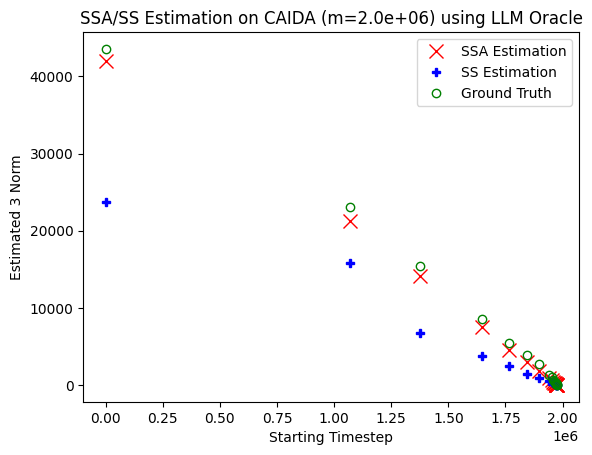

In [41]:
plot_estimates(timesteps, est_ssa, est_ss, gt, "LLM")

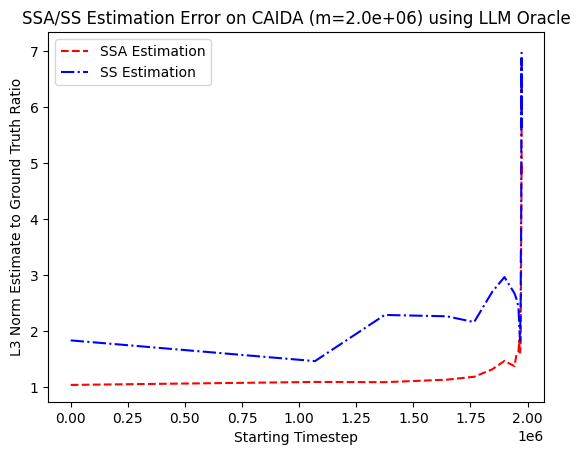

In [42]:
plot_error_ratio(timesteps, err_ssa, err_ss, "LLM")

In [43]:
# provide tabular results
from datetime import datetime

with open(f"Data/{datetime.now()}.txt", "w") as log:
    header = "{0:>18},{1:>18},{2:>18},{3:>18},{4:>18},{5:>18}".format("Ground Truth", "SSA Estimate", "SS Estimate", "SSA Error", "SS Error", "Timestep")
    print(header)
    log.write(header+"\n")
    for gti, ssa_est, ss_est, ssa_err, ss_err, time in zip(gt, est_ssa, est_ss, err_ssa, err_ss, timesteps):
        data_row = "{0:>18.3f},{1:>18.3f},{2:>18.3f},{3:>18.3f},{4:>18.3f},{5:>18.3f}".format(gti, ssa_est, ss_est, ssa_err, ss_err, time)
        print(data_row)
        log.write(data_row+"\n")

      Ground Truth,      SSA Estimate,       SS Estimate,         SSA Error,          SS Error,          Timestep
         43573.346,         42013.892,         23763.265,             1.037,             1.834,             1.000
         23116.553,         21207.331,         15804.199,             1.090,             1.463,       1069420.000
         15392.072,         14171.277,          6727.261,             1.086,             2.288,       1374556.000
          8518.798,          7533.261,          3761.891,             1.131,             2.264,       1646426.000
          5385.345,          4552.943,          2492.374,             1.183,             2.161,       1766070.000
          3843.061,          2920.323,          1422.253,             1.316,             2.702,       1845425.000
          2723.148,          1857.561,           918.326,             1.466,             2.965,       1898815.000
          1321.874,           962.194,           493.672,             1.374,            

## Test Parallel SS/SSA on Data - Vary Selection Probability

In [ ]:

q_range = [
    1/10, 1/20, 1/40, 1/80, 1/160, 1/320, 1/640
]

est_ssa_2 = []
est_ss_2 = []
gt_2 = []

for q in q_range:
    hist_ssa = {} # maps timestep to ssa value
    hist_ss = {} # maps timestep to ss value
    hist_hh_sums = {} # maps timestep to hh sum value
    threads_vec_ssa = [] # stores thread identities
    num_threads_max = 20 # hyperparam for max counters
    vals = []
    r1 = 3
    r2 = 5
    order = 3
    filepath="CAIDA/125910_ip_timestamps.csv"
    m = int(2e5)
    W = int(m/2) # window size
    sel_idx = m - W
    q_ss = q
    selective_subsampling_augmented(heavy=hh_gemini, filepath=filepath, order=order, limit=m, r1=r1, r2=r2, q=q, q_ss=q_ss)
    timesteps, est_ssa, est_ss, _, _, _ = calculate_estimates()
    diffs = np.absolute(np.array(timesteps)-sel_idx)
    est_idx = diffs.argmin()
    est_ssa_2.append(est_ssa[est_idx])
    est_ss_2.append(est_ss[est_idx])
    _, temp_freq = np.unique(vals[:-W], return_counts=True)
    gt_2.append(np.linalg.norm(temp_freq, order))

/var/folders/vm/qg92d4j56_l5x0q4g9hbq4j80000gn/T/ipykernel_30685/783967144.py:24: RuntimeWarning: invalid value encountered in scalar divide
  ratio = lambda x, y: max(x, y)/min(x, y)


### Visualize Results 

In [51]:
# provide tabular results
from datetime import datetime

with open(f"Data/{datetime.now()}.txt", "w") as log:
    header = "{0:>18},{1:>18},{2:>18},{3:>18}".format("Ground Truth", "SSA Estimate", "SS Estimate", "q")
    print(header)
    log.write(header+"\n")
    for gti_2, ssa_est_2, ss_est_2, q2 in zip(gt_2, est_ssa_2, est_ss_2, q_range):
        data_row = "{0:>18.3f},{1:>18.3f},{2:>18.3f},{3:>18.3f}".format(gti_2, ssa_est_2, ss_est_2, q2)
        print(data_row)
        log.write(data_row+"\n")

      Ground Truth,      SSA Estimate,       SS Estimate,                 q
          2498.500,          1829.794,          1158.541,             0.050


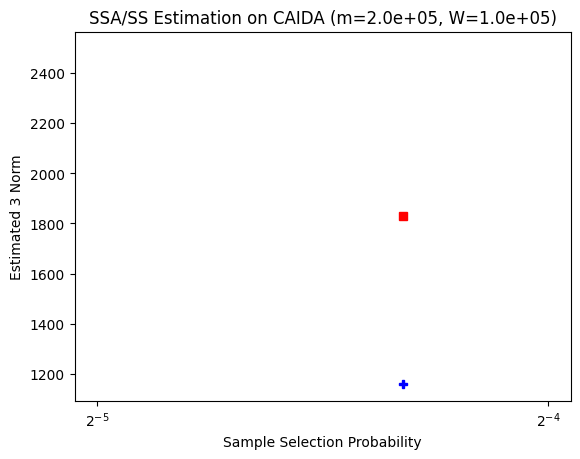

In [53]:
import matplotlib.pyplot as plt

_, ax = plt.subplots()

ax.plot(q_range, gt_2, 'g--', label='Ground Truth')
ax.plot(q_range, est_ss_2, 'bP', label='SS Estimation')
ax.plot(q_range, est_ssa_2, 'rs', label='SSA Estimation')
ax.set_xscale('log', base=2)
ax.set_title(f"SSA/SS Estimation on CAIDA (m={m:.1e}, W={W:.1e})")
ax.set_ylabel("Estimated 3 Norm")
ax.set_xlabel("Sample Selection Probability")
# ax.legend()
plt.show()